# Project 02 — Customer Behavior Analysis

## Business Context

I have been assigned as a Junior Data Analyst at an e-commerce company. The management team wants to use customer data to make better decisions about marketing budget, customer retention, loyalty programs, and discounts.

This project analyzes the cleaned customer dataset from **Project 01** and provides data-driven answers to the main business questions.

## Project Objectives

The main objectives of this analysis are to:

* Evaluate the overall status of customers.
* Identify the best city for the next marketing campaign.
* Select the 10 most valuable customers for a loyalty campaign.
* Identify customers who may be at risk of churn.
* Analyze the relationship between discount usage and customer behavior.
* Segment customers into meaningful behavioral groups.
* Analyze customer revenue concentration using Pareto analysis.
* Prepare a concise CEO dashboard.
* Provide three evidence-based recommendations for increasing sales.
* Identify the main limitations of the available dataset.

## Guiding Business Question

**How can customer data help the company make better marketing, retention, and sales decisions?**

## Data Source

The dataset used in this project is the cleaned dataset produced in **Project 01**.

**Input file:**

`cleaned_dataset.xlsx`

The dataset contains customer-level information such as:

* Customer ID
* Gender
* Age
* City
* Membership Tier
* Purchase Count
* Average Order Value
* Total Spending
* Last Purchase Days
* Payment Method
* Device
* Discount Usage
* Returned Items
* Satisfaction Score

## Analysis Approach

The analysis combines descriptive statistics, business analysis, customer ranking, churn-risk identification, customer segmentation, and Pareto analysis.

All findings are interpreted from a business perspective rather than being presented only as numbers or charts.

## Expected Outputs

The final project will produce:

1. Customer analysis results in Excel.
2. Business charts with titles and labeled axes.
3. A short management report in PDF format.
4. A `README.md` file documenting the analysis and findings.
5. A completed Jupyter Notebook containing the analysis and explanations.


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load and Inspect the Dataset

In this section, the cleaned customer dataset from Project 01 is loaded and inspected.

The purpose of this step is to verify:

* The number of rows and columns.
* The column names and data types.
* The presence of missing values.
* The presence of duplicate records.
* The general structure of the dataset.

The cleaned dataset is used as the input for all analyses in this project.


In [7]:
# Load the cleaned dataset

df = pd.read_excel("data/cleaned_dataset.xlsx")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 60
Columns: 17


In [8]:
# Display the first five rows

df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,True,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,False,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,True,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,False,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,True,7,4


### Dataset Structure

The following inspection checks the available variables and their data types. Correct data types are important because they determine how each variable can be used in the analysis.


In [9]:
# Display column names and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

### Missing Values Check

Missing values can affect statistical calculations and business conclusions. Since this dataset was cleaned in Project 01, the expectation is that no missing values remain.


In [10]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

Total missing cells: 0


### Duplicate Records Check

Duplicate records can cause customer counts and revenue calculations to be overstated. Therefore, duplicate rows are checked before starting the business analysis.


In [11]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Descriptive statistics for numerical variables

df.describe().T

,count,mean,min,25%,50%,75%,max,std
customer_id,60.0,1030.5,1001.0,1015.75,1030.5,1045.25,1060.0,17.464249
age,60.0,43.7,19.0,31.75,45.0,58.0,65.0,13.946994
signup_date,60,2023-02-03 14:00:00,2021-02-23 00:00:00,2021-12-06 12:00:00,2022-08-15 00:00:00,2024-06-14 12:00:00,2025-09-09 00:00:00,NaN
purchase_count,60.0,17.383333,0.0,10.75,17.0,24.5,35.0,10.14988
avg_order_value,60.0,213.1565,27.63,108.1375,165.435,324.1075,449.81,130.509923
total_spending,60.0,3366.428833,0.0,1167.035,2128.69,4213.1175,14354.34,3235.132979
last_purchase_days,60.0,198.6,3.0,134.25,203.0,273.75,365.0,97.843043
returned_items,60.0,3.8,0.0,1.0,3.5,6.0,8.0,2.666808
satisfaction_score,60.0,2.983333,1.0,2.0,3.0,4.0,5.0,1.431979


### Initial Data Findings

The dataset contains **60 customers** and provides information about customer demographics, purchasing behavior, spending, returns, satisfaction, and engagement.

The main observations from the descriptive statistics are:

* The average customer age is **43.7 years**, with ages ranging from 19 to 65.
* Customers make an average of **17.38 purchases**.
* The average order value is approximately **$213.16**.
* Average total customer spending is approximately **$3,366.43**, while the maximum is **$14,354.34**, indicating substantial differences in customer value.
* Customers have been inactive for an average of **198.6 days** since their last purchase.
* The average number of returned items is **3.8**.
* The average satisfaction score is **2.98 out of 5**, indicating a moderate level of customer satisfaction.
* The dataset contains **60 observations** for the main numerical variables.

These initial findings suggest that customer value and purchasing behavior vary considerably across the customer base. Therefore, further analysis is required to identify valuable customers, customers at risk of churn, and the most promising opportunities for increasing sales.


# Question 1 — Overall Customer Status

## Business Objective

The first step is to provide management with a clear overview of the current customer base.

The following key performance indicators (KPIs) will be calculated:

* Total number of customers
* Total number of purchases
* Total revenue
* Average spending per customer
* Average order value
* Average customer satisfaction
* Return rate

These indicators provide a high-level view of customer activity, revenue generation, satisfaction, and product return behavior.


In [13]:
# Question 1 — Calculate key business KPIs

total_customers = df["customer_id"].nunique()
total_purchases = df["purchase_count"].sum()
total_revenue = df["total_spending"].sum()

avg_spending_per_customer = df["total_spending"].mean()
avg_order_value = df["avg_order_value"].mean()
avg_satisfaction = df["satisfaction_score"].mean()

total_returned_items = df["returned_items"].sum()
return_rate = total_returned_items / total_purchases

print("===== Customer Overview =====")
print(f"Total Customers: {total_customers:,}")
print(f"Total Purchases: {total_purchases:,.0f}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Spending per Customer: ${avg_spending_per_customer:,.2f}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average Satisfaction: {avg_satisfaction:.2f} / 5")
print(f"Return Rate: {return_rate:.2%}")

===== Customer Overview =====
Total Customers: 60
Total Purchases: 1,043
Total Revenue: $201,985.73
Average Spending per Customer: $3,366.43
Average Order Value: $213.16
Average Satisfaction: 2.98 / 5
Return Rate: 21.86%


In [14]:
# Create a management KPI table

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Purchases",
        "Total Revenue",
        "Average Spending per Customer",
        "Average Order Value",
        "Average Satisfaction",
        "Return Rate"
    ],
    "Value": [
        total_customers,
        total_purchases,
        total_revenue,
        avg_spending_per_customer,
        avg_order_value,
        avg_satisfaction,
        return_rate
    ]
})

kpi_table

,KPI,Value
0,Total Customers,60.000000
1,Total Purchases,1043.000000
2,Total Revenue,201985.730000
3,Average Spending per Customer,3366.428833
4,Average Order Value,213.156500
5,Average Satisfaction,2.983333
6,Return Rate,0.218600


### Business Interpretation

The store currently has **60 customers** who generated **1,043 purchases** and approximately **$201,985.73 in total revenue**.

The average customer has spent approximately **$3,366.43**, while the average order value is about **$213.16**. This indicates that the existing customer base generates meaningful revenue, although customer spending varies considerably across the dataset.

The average satisfaction score is **2.98 out of 5**, which indicates a moderate customer experience and suggests that improving customer satisfaction should be considered an important business priority.

The overall return rate is approximately **21.86%**, meaning that around one out of every five purchased items is associated with a return. This is relatively high and may indicate potential issues related to product quality, customer expectations, fulfillment, or product selection.

### Management Conclusion

The business has a valuable existing customer base and generates approximately **$202K in recorded customer revenue**. However, the moderate satisfaction level and relatively high return rate represent important risks. Management should therefore focus not only on acquiring new customers, but also on improving customer experience, reducing returns, and retaining high-value customers.


### Revenue and Customer Value

The following chart highlights the total revenue generated by the customer base and the average spending per customer. These indicators help management understand the scale of the current customer base and its economic value.


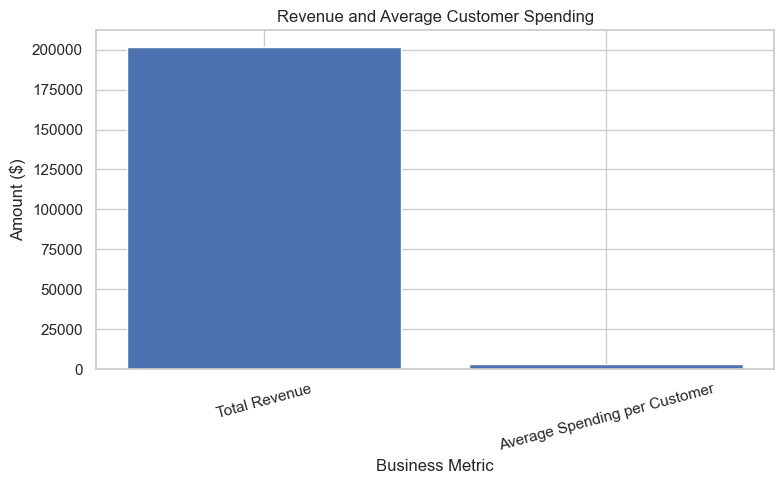

In [15]:
# Question 1 — Revenue and customer value chart

fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Total Revenue", "Average Spending per Customer"]
values = [total_revenue, avg_spending_per_customer]

ax.bar(labels, values)

ax.set_title("Revenue and Average Customer Spending")
ax.set_xlabel("Business Metric")
ax.set_ylabel("Amount ($)")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("01_revenue_customer_value.png", dpi=150, bbox_inches="tight")

plt.show()

# Question 2 — Selecting the Best City for Advertising

## Business Objective

The company has enough advertising budget to target only one city. The goal is to identify the city with the strongest combination of customer base, purchasing activity, revenue, customer value, satisfaction, and return performance.

The decision will not be based on total revenue alone. Multiple business indicators will be compared to identify the most attractive city for the next marketing campaign.


In [16]:
# Question 2 — City-level analysis

city_analysis = df.groupby("city").agg(
    customers=("customer_id", "nunique"),
    total_purchases=("purchase_count", "sum"),
    total_revenue=("total_spending", "sum"),
    avg_spending_per_customer=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    total_returned_items=("returned_items", "sum")
)

city_analysis["return_rate"] = (
    city_analysis["total_returned_items"] /
    city_analysis["total_purchases"]
)

city_analysis = city_analysis.sort_values(
    "total_revenue",
    ascending=False
)

city_analysis.round(2)

,customers,total_purchases,total_revenue,avg_spending_per_customer,avg_satisfaction,total_returned_items,return_rate
city,,,,,,,
Mashhad,11,249,43197.58,3927.05,2.91,29,0.12
Tabriz,12,189,36192.49,3016.04,3.00,50,0.26
Karaj,7,112,26189.81,3741.40,2.86,34,0.30
Ahvaz,8,111,23384.78,2923.10,3.50,26,0.23
Isfahan,5,99,21975.32,4395.06,4.40,22,0.22
Shiraz,6,98,20715.92,3452.65,2.00,29,0.30
Rasht,5,82,15168.54,3033.71,2.60,17,0.21
Tehran,6,103,15161.29,2526.88,2.67,21,0.20


In [17]:
city_analysis["revenue_share"] = (
    city_analysis["total_revenue"] / total_revenue
)

city_analysis.round(2)

,customers,total_purchases,total_revenue,avg_spending_per_customer,avg_satisfaction,total_returned_items,return_rate,revenue_share
city,,,,,,,,
Mashhad,11,249,43197.58,3927.05,2.91,29,0.12,0.21
Tabriz,12,189,36192.49,3016.04,3.00,50,0.26,0.18
Karaj,7,112,26189.81,3741.40,2.86,34,0.30,0.13
Ahvaz,8,111,23384.78,2923.10,3.50,26,0.23,0.12
Isfahan,5,99,21975.32,4395.06,4.40,22,0.22,0.11
Shiraz,6,98,20715.92,3452.65,2.00,29,0.30,0.10
Rasht,5,82,15168.54,3033.71,2.60,17,0.21,0.08
Tehran,6,103,15161.29,2526.88,2.67,21,0.20,0.08


In [18]:
# Management table for city comparison

city_result = city_analysis[
    [
        "customers",
        "total_purchases",
        "total_revenue",
        "avg_spending_per_customer",
        "avg_satisfaction",
        "return_rate"
    ]
].round(2)

city_result

,customers,total_purchases,total_revenue,avg_spending_per_customer,avg_satisfaction,return_rate
city,,,,,,
Mashhad,11,249,43197.58,3927.05,2.91,0.12
Tabriz,12,189,36192.49,3016.04,3.00,0.26
Karaj,7,112,26189.81,3741.40,2.86,0.30
Ahvaz,8,111,23384.78,2923.10,3.50,0.23
Isfahan,5,99,21975.32,4395.06,4.40,0.22
Shiraz,6,98,20715.92,3452.65,2.00,0.30
Rasht,5,82,15168.54,3033.71,2.60,0.21
Tehran,6,103,15161.29,2526.88,2.67,0.20


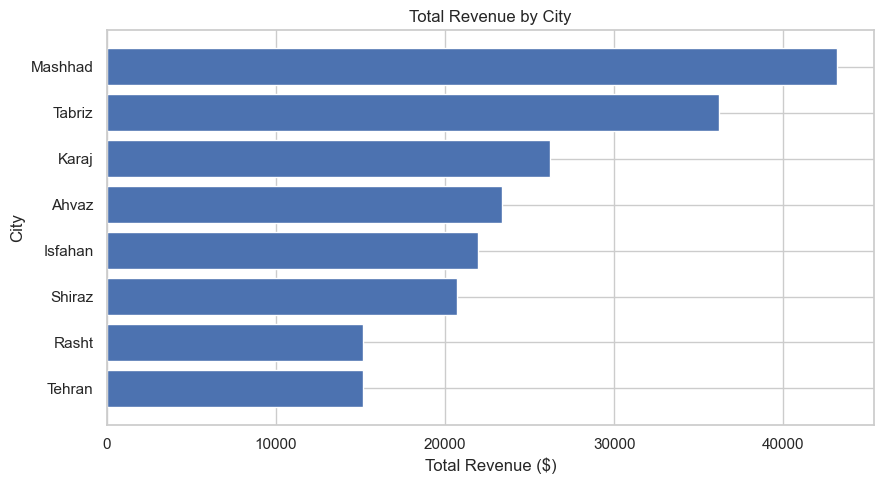

In [19]:
# Question 2 — Revenue by City

plt.figure(figsize=(9, 5))

city_plot = city_analysis.sort_values("total_revenue", ascending=True)

plt.barh(
    city_plot.index,
    city_plot["total_revenue"]
)

plt.title("Total Revenue by City")
plt.xlabel("Total Revenue ($)")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    "02_city_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### City Analysis — Management Interpretation

The analysis shows substantial differences between cities in terms of customer volume, purchasing activity, revenue, customer value, satisfaction, and return rate.

**Mashhad is selected as the best city for the next broad advertising campaign.**

Mashhad generates the highest total revenue at **$43,197.58**, representing approximately **21.4% of total company revenue**. It also has **11 customers** and the highest number of purchases (**249**) among all cities. Its average spending per customer is approximately **$3,927.05**, which is considerably higher than the company-wide average.

Mashhad also has a relatively low return rate of approximately **12%**, which is the lowest return rate among the cities in the dataset. This is an important positive signal because high sales combined with a high return rate could indicate operational or product-related problems.

However, Mashhad does not have the highest satisfaction score. **Isfahan has the highest satisfaction score at 4.40/5 and the highest average spending per customer at $4,395.06**, but its customer base contains only five customers. Therefore, Isfahan is more suitable for a smaller high-value customer campaign rather than the company's single broad advertising campaign.

Tabriz has the largest customer base with **12 customers**, but its average spending is lower than Mashhad and its return rate is considerably higher at approximately **26%**.

### Decision

Based on the combination of **revenue, number of purchases, customer volume, average customer spending, satisfaction, and return rate**, **Mashhad is the strongest overall choice for the next advertising campaign**.

The recommendation is therefore to allocate the main advertising budget to Mashhad while considering Isfahan as a smaller high-value test market.


### Risk / Limitation of the Decision

The main limitation is the **small sample size**. The entire dataset contains only 60 customers, and some cities have only five or six customers. Therefore, differences between cities may not represent the long-term behavior of the entire market.

In addition, the dataset does not contain **advertising costs, customer acquisition costs, profit margins, or conversion rates**. Therefore, the analysis identifies the city with the strongest existing customer performance, but it cannot determine which city would generate the highest return on advertising investment.

The recommendation should therefore be treated as a **data-informed starting point**, followed by a controlled advertising test in the selected city.


# Question 3 — Selecting 10 Customers for a Loyalty Campaign

## Business Objective

The company can provide a gift or purchase credit to only 10 customers. Therefore, the customers should be selected based on their overall customer value rather than total spending alone.

The selection considers:

* Total spending
* Purchase count
* Membership tier
* Satisfaction score
* Recency of the last purchase

The goal is to prioritize customers who have generated high value, show strong engagement, and are likely to respond positively to a loyalty program.


In [20]:
# Question 3 — Create a loyalty score

loyalty_df = df.copy()

# Standardize numerical variables
scaler = StandardScaler()

loyalty_df[
    ["spending_score", "purchase_score", "satisfaction_score_std", "recency_score"]
] = scaler.fit_transform(
    loyalty_df[
        [
            "total_spending",
            "purchase_count",
            "satisfaction_score",
            "last_purchase_days"
        ]
    ]
)

# Recency is reversed:
# fewer days since last purchase = better loyalty signal
loyalty_df["recency_score"] = -loyalty_df["recency_score"]

# Membership tier score
tier_scores = {
    "Bronze": 1,
    "Silver": 2,
    "Gold": 3,
    "VIP": 4
}

loyalty_df["tier_score"] = loyalty_df["membership_tier"].map(tier_scores)

# Standardize membership score
loyalty_df["tier_score_std"] = scaler.fit_transform(
    loyalty_df[["tier_score"]]
)

# Final loyalty score
loyalty_df["loyalty_score"] = (
    0.35 * loyalty_df["spending_score"] +
    0.25 * loyalty_df["purchase_score"] +
    0.15 * loyalty_df["tier_score_std"].ravel() +
    0.15 * loyalty_df["satisfaction_score_std"] +
    0.10 * loyalty_df["recency_score"]
)

loyalty_df[
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "total_spending",
        "purchase_count",
        "last_purchase_days",
        "satisfaction_score",
        "loyalty_score"
    ]
].sort_values(
    "loyalty_score",
    ascending=False
).head(10)

C:\Users\Smah\AppData\Local\Temp\ipykernel_25116\243818244.py:44: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  0.15 * loyalty_df["tier_score_std"].ravel() +


,customer_id,first_name,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,loyalty_score
43,1044,Mina,Gold,14354.34,33,165,2,1.579842
56,1057,Maryam,Bronze,13532.74,31,82,4,1.479117
58,1059,Ali,Gold,8898.55,31,224,5,1.191030
8,1009,Kimia,Silver,11615.42,34,232,2,1.107697
11,1012,Arash,Gold,11731.50,27,224,2,1.083848
32,1033,Neda,VIP,5521.20,24,112,5,0.893237
3,1004,Sina,Gold,6121.45,23,40,4,0.773347
13,1014,Reza,VIP,3353.89,31,97,4,0.740480
16,1017,Parsa,VIP,3239.40,30,135,4,0.663985
6,1007,Reza,VIP,2237.35,29,298,5,0.467457


In [21]:
# Select the top 10 customers

top10_customers = (
    loyalty_df
    .sort_values("loyalty_score", ascending=False)
    .head(10)
    .copy()
)

top10_customers[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "loyalty_score"
    ]
]

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,1.579842
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,1.479117
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5,1.191030
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2,1.107697
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2,1.083848
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,0.893237
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,0.773347
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,0.740480
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,0.663985
6,1007,Reza,Rasht,VIP,29,2237.35,298,5,0.467457


In [22]:
def selection_reason(row):
    reasons = []

    if row["total_spending"] >= df["total_spending"].median():
        reasons.append("high spending")

    if row["purchase_count"] >= df["purchase_count"].median():
        reasons.append("frequent purchases")

    if row["satisfaction_score"] >= df["satisfaction_score"].median():
        reasons.append("good satisfaction")

    if row["last_purchase_days"] <= df["last_purchase_days"].median():
        reasons.append("recent purchase")

    if row["membership_tier"] in ["Gold", "VIP"]:
        reasons.append("high membership tier")

    return ", ".join(reasons)


top10_customers["reason_for_selection"] = (
    top10_customers.apply(selection_reason, axis=1)
)

In [23]:
# Final loyalty campaign table

loyalty_result = top10_customers[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "reason_for_selection"
    ]
].copy()

loyalty_result.columns = [
    "Customer ID",
    "Customer Name",
    "City",
    "Membership Tier",
    "Purchase Count",
    "Total Spending",
    "Last Purchase Days",
    "Satisfaction Score",
    "Reason for Selection"
]

loyalty_result

,Customer ID,Customer Name,City,Membership Tier,Purchase Count,Total Spending,Last Purchase Days,Satisfaction Score,Reason for Selection
43,1044,Mina,Shiraz,Gold,33,14354.34,165,2,"high spending, frequent purchases, recent purc..."
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,"high spending, frequent purchases, good satisf..."
58,1059,Ali,Isfahan,Gold,31,8898.55,224,5,"high spending, frequent purchases, good satisf..."
8,1009,Kimia,Karaj,Silver,34,11615.42,232,2,"high spending, frequent purchases"
11,1012,Arash,Mashhad,Gold,27,11731.50,224,2,"high spending, frequent purchases, high member..."
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,"high spending, frequent purchases, good satisf..."
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,"high spending, frequent purchases, good satisf..."
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,"high spending, frequent purchases, good satisf..."
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,"high spending, frequent purchases, good satisf..."
6,1007,Reza,Rasht,VIP,29,2237.35,298,5,"high spending, frequent purchases, good satisf..."


In [25]:
# Final Question 3 table

loyalty_result = loyalty_result.reset_index(drop=True)

loyalty_result

loyalty_result.to_excel(
    "question_03_loyalty_customers.xlsx",
    index=False
)

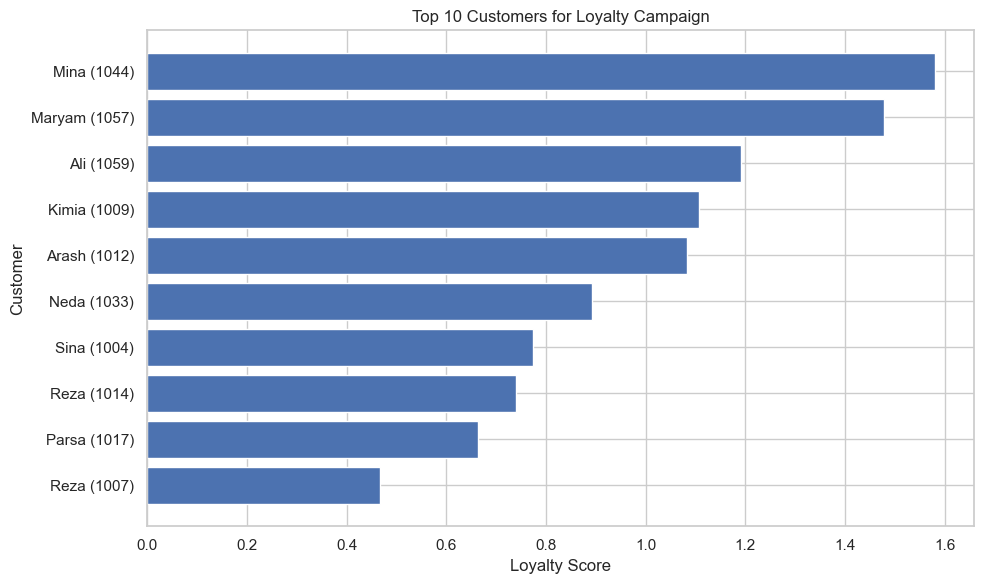

In [26]:
# Question 3 — Top 10 Customers for Loyalty Campaign

plt.figure(figsize=(10, 6))

plot_data = top10_customers.sort_values(
    "loyalty_score",
    ascending=True
)

plt.barh(
    plot_data["first_name"] + " (" + plot_data["customer_id"].astype(str) + ")",
    plot_data["loyalty_score"]
)

plt.title("Top 10 Customers for Loyalty Campaign")
plt.xlabel("Loyalty Score")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    "03_top10_loyalty_customers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Management Interpretation

The 10 customers were selected using a combined Loyalty Score based on total spending, purchase frequency, membership tier, satisfaction, and recency.

The selected customers include several high-value customers with very high total spending and frequent purchases. For example, **Mina (Customer ID 1044)** has the highest total spending in the selected group at **$14,354.34** and has made **33 purchases**. **Maryam (Customer ID 1057)** has generated **$13,532.74** from **31 purchases** and has a satisfaction score of **4/5**, making her an especially strong loyalty candidate.

Other selected customers combine high purchase frequency with high satisfaction or valuable membership levels. This means the campaign is not based solely on spending; it also considers engagement, satisfaction, membership status, and recent activity.

### Business Decision

The company should provide the selected 10 customers with loyalty benefits such as purchase credit, exclusive offers, early access to new products, or personalized rewards.

The highest-value customers should receive the most valuable rewards, while customers with strong engagement and satisfaction should receive incentives designed to maintain their current purchasing behavior.


# Question 4 — Identifying Customers at Risk of Churn

## Business Objective

Some customers have generated significant revenue for the company but have not purchased recently. These customers may be at risk of churn.

The objective is to identify high-value customers with long periods since their last purchase and recommend an appropriate retention action.


In [27]:
# Question 4 — Define churn-risk customers

spending_threshold = df["total_spending"].median()
recency_threshold = df["last_purchase_days"].quantile(0.75)

print("High-value spending threshold:", round(spending_threshold, 2))
print("High recency threshold:", round(recency_threshold, 2))

df["at_risk"] = (
    (df["total_spending"] >= spending_threshold) &
    (df["last_purchase_days"] >= recency_threshold)
)

print(
    f"At-risk customers: {df['at_risk'].sum()} "
    f"out of {len(df)} "
    f"({df['at_risk'].mean():.1%})"
)

High-value spending threshold: 2128.69
High recency threshold: 273.75
At-risk customers: 7 out of 60 (11.7%)


In [28]:
at_risk_customers = df.loc[
    df["at_risk"],
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].sort_values(
    "total_spending",
    ascending=False
)

at_risk_customers

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Karaj,Silver,19,7241.47,276,1
34,1035,Arash,Tabriz,Bronze,17,5918.21,365,3
52,1053,Sina,Tehran,Gold,18,5805.54,320,1
29,1030,Sina,Mashhad,VIP,26,4079.14,340,4
53,1054,Reza,Tabriz,Gold,9,3691.44,304,1
6,1007,Reza,Rasht,VIP,29,2237.35,298,5
48,1049,Ali,Mashhad,Gold,23,2140.38,357,1


In [31]:
at_risk_revenue = at_risk_customers["total_spending"].sum()

print(f"Historical revenue from at-risk customers: ${at_risk_revenue:,.2f}")
print(f"Number of at-risk customers: {len(at_risk_customers)}")

at_risk_customers

Historical revenue from at-risk customers: $31,113.53
Number of at-risk customers: 7


,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Karaj,Silver,19,7241.47,276,1
34,1035,Arash,Tabriz,Bronze,17,5918.21,365,3
52,1053,Sina,Tehran,Gold,18,5805.54,320,1
29,1030,Sina,Mashhad,VIP,26,4079.14,340,4
53,1054,Reza,Tabriz,Gold,9,3691.44,304,1
6,1007,Reza,Rasht,VIP,29,2237.35,298,5
48,1049,Ali,Mashhad,Gold,23,2140.38,357,1


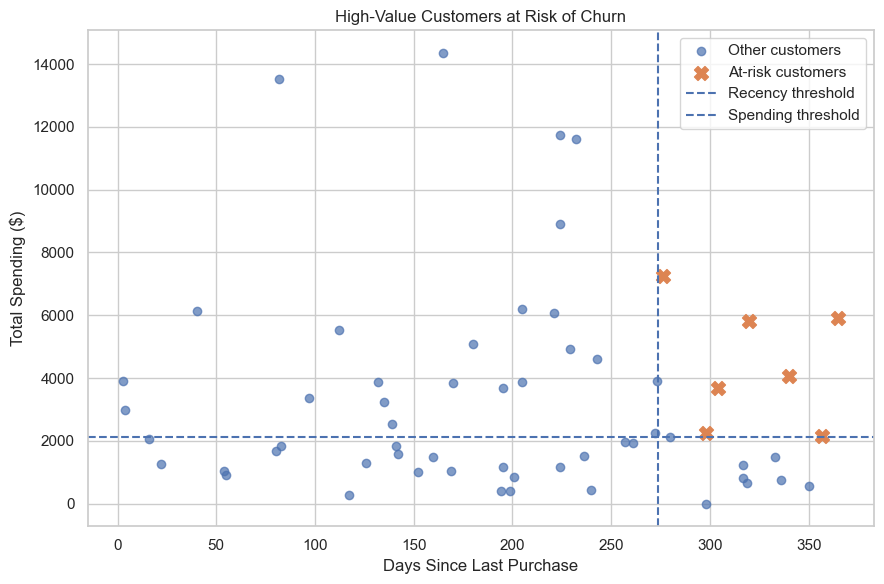

In [30]:
# Question 4 — Churn Risk Map

plt.figure(figsize=(9, 6))

plt.scatter(
    df.loc[~df["at_risk"], "last_purchase_days"],
    df.loc[~df["at_risk"], "total_spending"],
    label="Other customers",
    alpha=0.7
)

plt.scatter(
    df.loc[df["at_risk"], "last_purchase_days"],
    df.loc[df["at_risk"], "total_spending"],
    label="At-risk customers",
    s=100,
    marker="X"
)

plt.axvline(
    recency_threshold,
    linestyle="--",
    label="Recency threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Spending threshold"
)

plt.title("High-Value Customers at Risk of Churn")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending ($)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "04_churn_risk.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Management Interpretation

Customers were classified as at risk when they had both relatively high historical spending and a long period since their last purchase.

The analysis identifies customers who are financially valuable but may be becoming inactive. These customers should receive higher retention priority because losing them could result in a meaningful loss of future revenue.

The most appropriate strategy is not to send the same promotion to every customer. High-value customers should receive personalized win-back offers based on their previous purchasing behavior, such as exclusive discounts, purchase credit, free shipping, or personalized product recommendations.

### Recommended Retention Action

The company should launch a targeted **win-back campaign** for these customers. The campaign should provide a personalized incentive and a limited redemption period to encourage the customer to return.

The company should monitor the percentage of targeted customers who make another purchase after receiving the campaign.
### Definition of an At-Risk Customer

For this analysis, an **at-risk customer** is defined as a customer whose total spending is at or above the median customer spending and whose number of days since the last purchase is at or above the 75th percentile of the dataset.

This definition identifies customers who have demonstrated relatively high historical value but have recently become inactive.


# Question 4 — Customers at Risk of Churn

## Definition

A customer is classified as **at risk of churn** when their total spending is at or above the median customer spending and their number of days since the last purchase is at or above the 75th percentile.

This definition focuses on customers who have demonstrated relatively high historical value but have become inactive.

## Results

The analysis identified **7 at-risk customers out of 60 customers**. These customers have generated a combined historical revenue of **$31,113.53**, representing approximately **15.4% of total company revenue**.

Several customers show particularly concerning signals. For example, Customer 1010 has spent **$7,241.47** but has not purchased for **276 days** and has a satisfaction score of only **1/5**. Customer 1035 has spent **$5,918.21** and has been inactive for **365 days**. Customer 1053 has generated **$5,805.54**, has not purchased for **320 days**, and also has a satisfaction score of **1/5**.

These customers represent an important retention opportunity because the company has already established a purchasing relationship with them.

## Recommended Action

The company should launch a targeted **win-back campaign** for these seven customers instead of using a general discount campaign.

The campaign could include:

* Personalized purchase-credit offers
* Free shipping
* Exclusive discounts
* Personalized product recommendations
* A limited redemption period

Customers with both high spending and very low satisfaction should receive special attention from customer support before receiving a promotional offer.

## Business Interpretation

The seven customers should be considered a high-priority retention group. Recovering even a portion of their future purchases could protect a meaningful amount of customer value.

However, the result should not be interpreted as confirmed churn because the dataset does not contain an actual churn label or transaction history. The definition used here is a data-driven risk indicator rather than proof that these customers have permanently stopped purchasing.


# Question 5 — Discount Effect on Customer Behavior

## Business Objective

The sales manager believes that discounts increase customer purchases, while the finance manager is concerned that discounts may reduce revenue without creating meaningful additional value.

This analysis compares customers who used discounts with customers who did not use discounts using:

* Number of customers
* Total purchases
* Average purchases per customer
* Average spending per customer
* Average satisfaction
* Return rate

The goal is to determine whether the available data provides evidence that discounts are associated with higher sales performance.


In [32]:
# Question 5 — Discount comparison

discount_analysis = df.groupby("discount_used").agg(
    customers=("customer_id", "nunique"),
    total_purchases=("purchase_count", "sum"),
    avg_purchases=("purchase_count", "mean"),
    avg_spending=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    total_returned_items=("returned_items", "sum")
)

discount_analysis["return_rate"] = (
    discount_analysis["total_returned_items"] /
    discount_analysis["total_purchases"]
)

discount_analysis = discount_analysis.round(2)

discount_analysis

,customers,total_purchases,avg_purchases,avg_spending,avg_satisfaction,total_returned_items,return_rate
discount_used,,,,,,,
False,34,588,17.29,3736.74,2.76,135,0.23
True,26,455,17.50,2882.17,3.27,93,0.20


In [33]:
discount_result = discount_analysis.copy()

discount_result.index = discount_result.index.map({
    True: "Used Discount",
    False: "No Discount"
})

discount_result

,customers,total_purchases,avg_purchases,avg_spending,avg_satisfaction,total_returned_items,return_rate
discount_used,,,,,,,
No Discount,34,588,17.29,3736.74,2.76,135,0.23
Used Discount,26,455,17.50,2882.17,3.27,93,0.20


In [34]:
# Statistical comparison

discount_group = df[df["discount_used"] == True]
no_discount_group = df[df["discount_used"] == False]

t_purchase, p_purchase = stats.ttest_ind(
    discount_group["purchase_count"],
    no_discount_group["purchase_count"],
    equal_var=False
)

t_spending, p_spending = stats.ttest_ind(
    discount_group["total_spending"],
    no_discount_group["total_spending"],
    equal_var=False
)

print(f"Purchase Count: t = {t_purchase:.2f}, p = {p_purchase:.4f}")
print(f"Total Spending: t = {t_spending:.2f}, p = {p_spending:.4f}")

Purchase Count: t = 0.08, p = 0.9393
Total Spending: t = -1.05, p = 0.2967


In [36]:
# Question 5 — Discount comparison

discount_group = df[df["discount_used"] == True]
no_discount_group = df[df["discount_used"] == False]

# Calculate return rate separately
discount_return_rate = (
    discount_group["returned_items"].sum() /
    discount_group["purchase_count"].sum()
)

no_discount_return_rate = (
    no_discount_group["returned_items"].sum() /
    no_discount_group["purchase_count"].sum()
)

print("=== Discount Users ===")
print("Customers:", len(discount_group))
print("Total purchases:", discount_group["purchase_count"].sum())
print("Average purchases:", round(discount_group["purchase_count"].mean(), 2))
print("Average spending:", round(discount_group["total_spending"].mean(), 2))
print("Average satisfaction:", round(discount_group["satisfaction_score"].mean(), 2))
print("Return rate:", round(discount_return_rate * 100, 2), "%")

print("\n=== Non-Discount Users ===")
print("Customers:", len(no_discount_group))
print("Total purchases:", no_discount_group["purchase_count"].sum())
print("Average purchases:", round(no_discount_group["purchase_count"].mean(), 2))
print("Average spending:", round(no_discount_group["total_spending"].mean(), 2))
print("Average satisfaction:", round(no_discount_group["satisfaction_score"].mean(), 2))
print("Return rate:", round(no_discount_return_rate * 100, 2), "%")

=== Discount Users ===
Customers: 26
Total purchases: 455
Average purchases: 17.5
Average spending: 2882.17
Average satisfaction: 3.27
Return rate: 20.44 %

=== Non-Discount Users ===
Customers: 34
Total purchases: 588
Average purchases: 17.29
Average spending: 3736.74
Average satisfaction: 2.76
Return rate: 22.96 %


In [38]:
from pathlib import Path

Path("charts").mkdir(parents=True, exist_ok=True)

print("Charts folder is ready.")

Charts folder is ready.


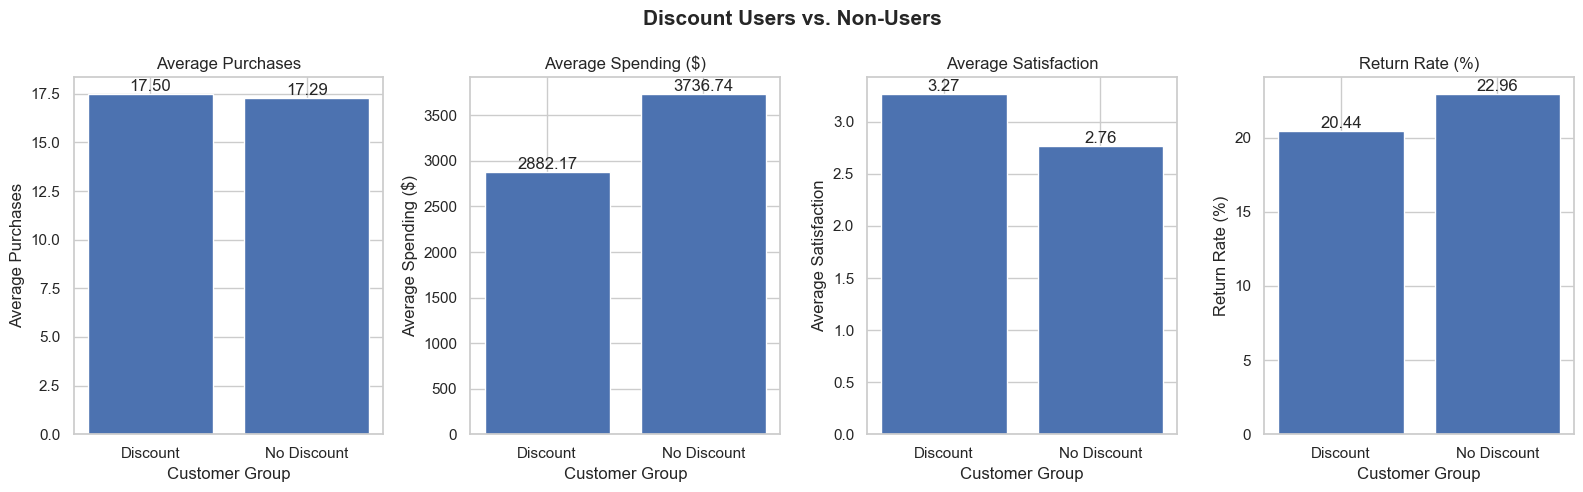

In [39]:
# Question 5 — Discount comparison chart

metrics = [
    ("Average Purchases", 
     discount_group["purchase_count"].mean(),
     no_discount_group["purchase_count"].mean()),

    ("Average Spending ($)", 
     discount_group["total_spending"].mean(),
     no_discount_group["total_spending"].mean()),

    ("Average Satisfaction", 
     discount_group["satisfaction_score"].mean(),
     no_discount_group["satisfaction_score"].mean()),

    ("Return Rate (%)", 
     discount_return_rate * 100,
     no_discount_return_rate * 100)
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (title, discount_value, no_discount_value) in zip(axes, metrics):

    ax.bar(
        ["Discount", "No Discount"],
        [discount_value, no_discount_value]
    )

    ax.set_title(title)
    ax.set_xlabel("Customer Group")
    ax.set_ylabel(title)

    # Display values on bars
    ax.text(
        0,
        discount_value,
        f"{discount_value:.2f}",
        ha="center",
        va="bottom"
    )

    ax.text(
        1,
        no_discount_value,
        f"{no_discount_value:.2f}",
        ha="center",
        va="bottom"
    )

plt.suptitle(
    "Discount Users vs. Non-Users",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/05_discount_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Statistical tests

t_purchase, p_purchase = stats.ttest_ind(
    discount_group["purchase_count"],
    no_discount_group["purchase_count"],
    equal_var=False
)

t_spending, p_spending = stats.ttest_ind(
    discount_group["total_spending"],
    no_discount_group["total_spending"],
    equal_var=False
)

print("Statistical Test Results")
print("------------------------")

print(
    f"Purchase Count: "
    f"t = {t_purchase:.2f}, "
    f"p-value = {p_purchase:.4f}"
)

print(
    f"Total Spending: "
    f"t = {t_spending:.2f}, "
    f"p-value = {p_spending:.4f}"
)

Statistical Test Results
------------------------
Purchase Count: t = 0.08, p-value = 0.9393
Total Spending: t = -1.05, p-value = 0.2967


### Interpretation

The comparison shows differences between customers who used discounts and those who did not. However, a difference between the two groups does not necessarily mean that discounts caused the difference.

Because this dataset is observational and customers were not randomly assigned to receive discounts, other factors may explain the observed differences. Therefore, the results should be interpreted as an association rather than a causal effect.

A statistical test is also used to determine whether the differences in purchase count and total spending are statistically significant.


# Question 6 — Customer Segmentation

## Objective

Customers are segmented into four actionable groups based on their purchasing behavior, spending, recency, and satisfaction.

The four segments are:

* **Champions**
* **Loyal Customers**
* **At Risk**
* **Needs Attention**

The purpose of this segmentation is to identify the appropriate business action for each customer group.


In [41]:
# Question 6 — Customer Segmentation

seg_df = df.copy()

# Calculate percentile thresholds
spending_75 = seg_df["total_spending"].quantile(0.75)
purchase_75 = seg_df["purchase_count"].quantile(0.75)
recency_75 = seg_df["last_purchase_days"].quantile(0.75)

spending_25 = seg_df["total_spending"].quantile(0.25)
purchase_25 = seg_df["purchase_count"].quantile(0.25)
recency_25 = seg_df["last_purchase_days"].quantile(0.25)

print("Thresholds:")
print(f"Spending 75th percentile: ${spending_75:,.2f}")
print(f"Purchase 75th percentile: {purchase_75:.2f}")
print(f"Recency 75th percentile: {recency_75:.2f} days")

Thresholds:
Spending 75th percentile: $4,213.12
Purchase 75th percentile: 24.50
Recency 75th percentile: 273.75 days


In [43]:
def assign_segment(row):

    # Champions:
    # High spending + frequent purchases + recent activity
    if (
        row["total_spending"] >= spending_75
        and row["purchase_count"] >= purchase_75
        and row["last_purchase_days"] <= recency_25
    ):
        return "Champions"

    # At Risk:
    # High spending + long time since last purchase
    elif (
        row["total_spending"] >= spending_75
        and row["last_purchase_days"] >= recency_75
    ):
        return "At Risk"

    # Loyal Customers:
    # Good purchase frequency and relatively recent activity
    elif (
        row["purchase_count"] >= purchase_25
        and row["last_purchase_days"] <= recency_25
        and row["satisfaction_score"] >= 3
    ):
        return "Loyal Customers"

    # Everyone else
    else:
        return "Needs Attention"


seg_df["segment"] = seg_df.apply(assign_segment, axis=1)

seg_df["segment"].value_counts()

segment
Needs Attention    48
Loyal Customers     8
At Risk             3
Champions           1
Name: count, dtype: int64

In [44]:
segment_summary = seg_df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_spending=("total_spending", "mean"),
    avg_recency=("last_purchase_days", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    total_revenue=("total_spending", "sum")
).round(2)

segment_summary

,customers,avg_purchase_count,avg_spending,avg_recency,avg_satisfaction,total_revenue
segment,,,,,,
At Risk,3,18.00,6321.74,320.33,1.67,18965.22
Champions,1,31.00,13532.74,82.00,4.00,13532.74
Loyal Customers,8,19.88,3337.68,50.75,4.12,26701.47
Needs Attention,48,16.65,2974.71,218.06,2.85,142786.30


In [45]:
segment_customers = seg_df[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "segment"
    ]
].sort_values(
    ["segment", "total_spending"],
    ascending=[True, False]
)

segment_customers

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,segment
9,1010,Arash,Karaj,Silver,19,7241.47,276,1,At Risk
34,1035,Arash,Tabriz,Bronze,17,5918.21,365,3,At Risk
52,1053,Sina,Tehran,Gold,18,5805.54,320,1,At Risk
56,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,Champions
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,Loyal Customers
32,1033,Neda,Tabriz,VIP,24,5521.20,112,5,Loyal Customers
1,1002,Sina,Tehran,Gold,12,3917.64,3,3,Loyal Customers
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,Loyal Customers
19,1020,Kimia,Isfahan,Bronze,16,2994.72,4,5,Loyal Customers
0,1001,Reza,Karaj,VIP,17,2066.01,16,5,Loyal Customers


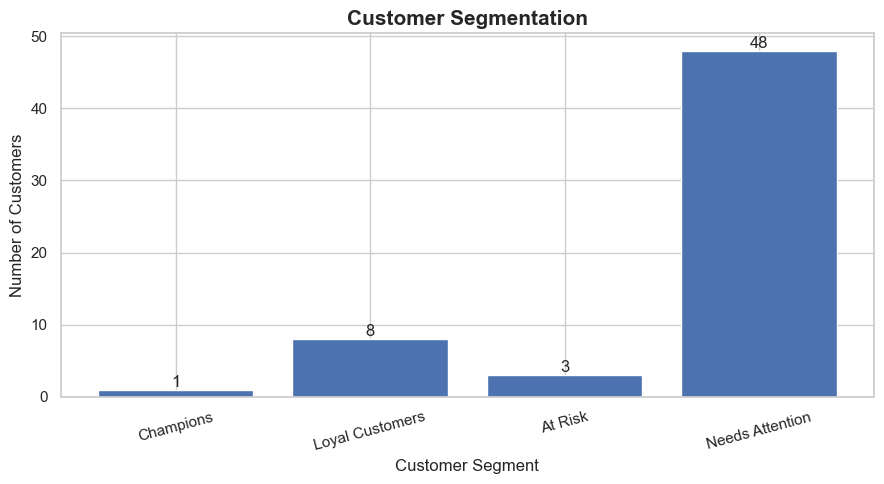

In [46]:
# Customer Segmentation Chart

segment_order = [
    "Champions",
    "Loyal Customers",
    "At Risk",
    "Needs Attention"
]

segment_counts = (
    seg_df["segment"]
    .value_counts()
    .reindex(segment_order)
    .fillna(0)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title(
    "Customer Segmentation",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "charts/06_customer_segmentation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Segment Interpretation and Business Actions

### 1. Champions

**Who are they?**
Customers with high total spending, frequent purchases, and recent purchasing activity.

**Main characteristic:**
They are the most valuable and currently engaged customers.

**Recommended action:**
Protect their loyalty through VIP treatment, exclusive offers, early access to new products, and personalized rewards.

---

### 2. Loyal Customers

**Who are they?**
Customers who purchase relatively frequently, have recent activity, and report acceptable satisfaction.

**Main characteristic:**
They show stable engagement and have the potential to become Champions.

**Recommended action:**
Encourage repeat purchases through personalized recommendations, loyalty points, and targeted promotions.

---

### 3. At Risk

**Who are they?**
Customers with relatively high historical spending but a long period since their last purchase.

**Main characteristic:**
The company has already generated significant revenue from these customers, but their recent engagement is weak.

**Recommended action:**
Launch a targeted win-back campaign using personalized messages, limited-time incentives, and customer-service follow-up.

---

### 4. Needs Attention

**Who are they?**
Customers who do not meet the criteria for the other three segments.

**Main characteristic:**
Their purchasing activity, spending, recency, or satisfaction requires further improvement.

**Recommended action:**
Use low-cost engagement campaigns, personalized recommendations, and satisfaction-improvement actions before allocating expensive retention incentives.


## Interpretation of Customer Segments

### 1. Champions

This group contains only **1 customer**, but this customer has very high value, with **31 purchases**, average spending of **$13,532.74**, and a satisfaction score of **4.0/5**.

**Main characteristic:** Highly valuable, active, and satisfied customer.

**Recommended action:** Protect this customer through VIP benefits, personalized offers, exclusive rewards, and early access to new products.

### 2. Loyal Customers

This group contains **8 customers** with an average of **19.88 purchases**, average spending of **$3,337.68**, and a high satisfaction score of **4.12/5**. They are active and satisfied customers with strong potential to become Champions.

**Main characteristic:** Frequent purchases, high satisfaction, and stable customer engagement.

**Recommended action:** Use loyalty rewards, personalized promotions, and repeat-purchase incentives to increase their customer value.

### 3. At Risk

This group contains **3 customers** with relatively high average spending of **$6,321.74**, but they have not purchased for an average of **320 days**. Their average satisfaction score is also very low at **1.67/5**.

**Main characteristic:** High historical value but strong signs of disengagement and dissatisfaction.

**Recommended action:** Prioritize these customers in a win-back campaign using personalized offers, limited-time incentives, and customer-service follow-up.

### 4. Needs Attention

This is the largest group, containing **48 customers**. They generate approximately **$142,786.30** in total revenue. However, their average recency is **218.06 days** and their average satisfaction score is only **2.85/5**.

**Main characteristic:** Large customer base with moderate spending, relatively long purchase gaps, and moderate satisfaction.

**Recommended action:** Use cost-effective reactivation campaigns, personalized promotions, and customer satisfaction initiatives to increase engagement and repeat purchases.

### Management Conclusion

The analysis shows that the company should not focus only on the **Champions** segment. Although Champions are extremely valuable, the **Needs Attention** group represents the largest opportunity because it contains **48 customers and generates the highest total revenue ($142,786.30)**.

Therefore, the recommended strategy is to **protect Champions, develop Loyal Customers, win back At Risk customers, and gradually reactivate the Needs Attention segment**.


In [47]:
# Question 7 — Pareto Analysis

# Sort customers by total spending from highest to lowest
pareto_df = df[["customer_id", "first_name", "total_spending"]].copy()
pareto_df = pareto_df.sort_values("total_spending", ascending=False).reset_index(drop=True)

# Calculate cumulative revenue
pareto_df["cumulative_revenue"] = pareto_df["total_spending"].cumsum()
pareto_df["cumulative_revenue_pct"] = (
    pareto_df["cumulative_revenue"] / pareto_df["total_spending"].sum()
) * 100

# Customer percentage
pareto_df["customer_pct"] = (
    (pareto_df.index + 1) / len(pareto_df)
) * 100

# Top 20% of customers
top_20_count = int(np.ceil(len(pareto_df) * 0.20))

top_20_revenue = pareto_df.head(top_20_count)["total_spending"].sum()
total_revenue = pareto_df["total_spending"].sum()

top_20_revenue_pct = (top_20_revenue / total_revenue) * 100

print(f"Total customers: {len(pareto_df)}")
print(f"Top 20% customers: {top_20_count}")
print(f"Revenue generated by top 20%: {top_20_revenue_pct:.2f}%")

Total customers: 60
Top 20% customers: 12
Revenue generated by top 20%: 51.00%


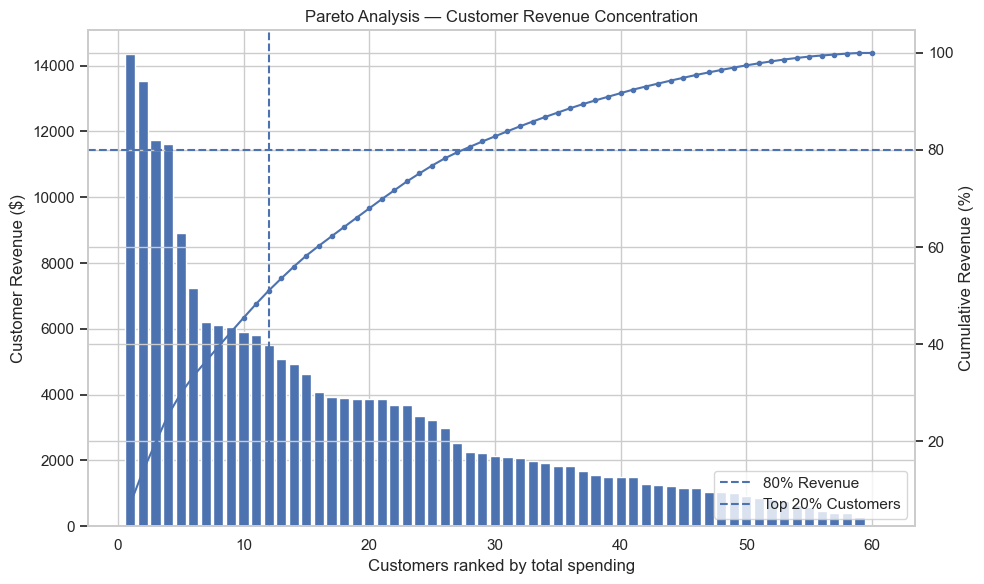

In [48]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Revenue bars
ax1.bar(
    range(1, len(pareto_df) + 1),
    pareto_df["total_spending"]
)

ax1.set_xlabel("Customers ranked by total spending")
ax1.set_ylabel("Customer Revenue ($)")
ax1.set_title("Pareto Analysis — Customer Revenue Concentration")

# Cumulative revenue line
ax2 = ax1.twinx()

ax2.plot(
    range(1, len(pareto_df) + 1),
    pareto_df["cumulative_revenue_pct"],
    marker="o",
    markersize=3
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1.5,
    label="80% Revenue"
)

ax2.axvline(
    top_20_count,
    linestyle="--",
    linewidth=1.5,
    label="Top 20% Customers"
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "charts/07_pareto_analysis.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [50]:
# Create customer segments for each customer

def assign_segment(row):
    if (
        row["total_spending"] >= df["total_spending"].quantile(0.75)
        and row["purchase_count"] >= df["purchase_count"].quantile(0.75)
        and row["last_purchase_days"] <= df["last_purchase_days"].median()
        and row["satisfaction_score"] >= 4
    ):
        return "Champions"

    elif (
        row["purchase_count"] >= df["purchase_count"].median()
        and row["last_purchase_days"] <= df["last_purchase_days"].median()
        and row["satisfaction_score"] >= 4
    ):
        return "Loyal Customers"

    elif (
        row["total_spending"] >= df["total_spending"].median()
        and row["last_purchase_days"] >= df["last_purchase_days"].quantile(0.75)
    ):
        return "At Risk"

    else:
        return "Needs Attention"


df["segment"] = df.apply(assign_segment, axis=1)

print("Customer segmentation completed.")
print()
print(df["segment"].value_counts())

Customer segmentation completed.

segment
Needs Attention    44
Loyal Customers     8
At Risk             7
Champions           1
Name: count, dtype: int64


## Question 7 — Revenue Concentration (Pareto Analysis)

### Analysis Objective

This section examines whether a small proportion of customers generates a large share of the company's total revenue.

To perform this analysis, **Pareto Analysis** is used. Customers are first ranked from highest to lowest based on `total_spending`. The top 20% of customers are then identified, and their contribution to total revenue is calculated.

### Result

The dataset contains **60 customers**.

Therefore, the top 20% of customers represent:

**12 customers**

These 12 customers generate approximately:

**51% of total revenue.**

### Business Interpretation

The results show that the company's revenue is meaningfully concentrated among high-value customers. However, the classic **80/20 rule** is not observed because the top 20% of customers generate approximately 51% of revenue rather than 80%.

This indicates that high-value customers are important to the business and should receive special attention through loyalty programs, personalized offers, and retention strategies.

### Conclusion

**The top 20% of customers (12 customers) generate approximately 51% of total revenue.**

This demonstrates a significant concentration of revenue among high-value customers and highlights the importance of retaining these customers.


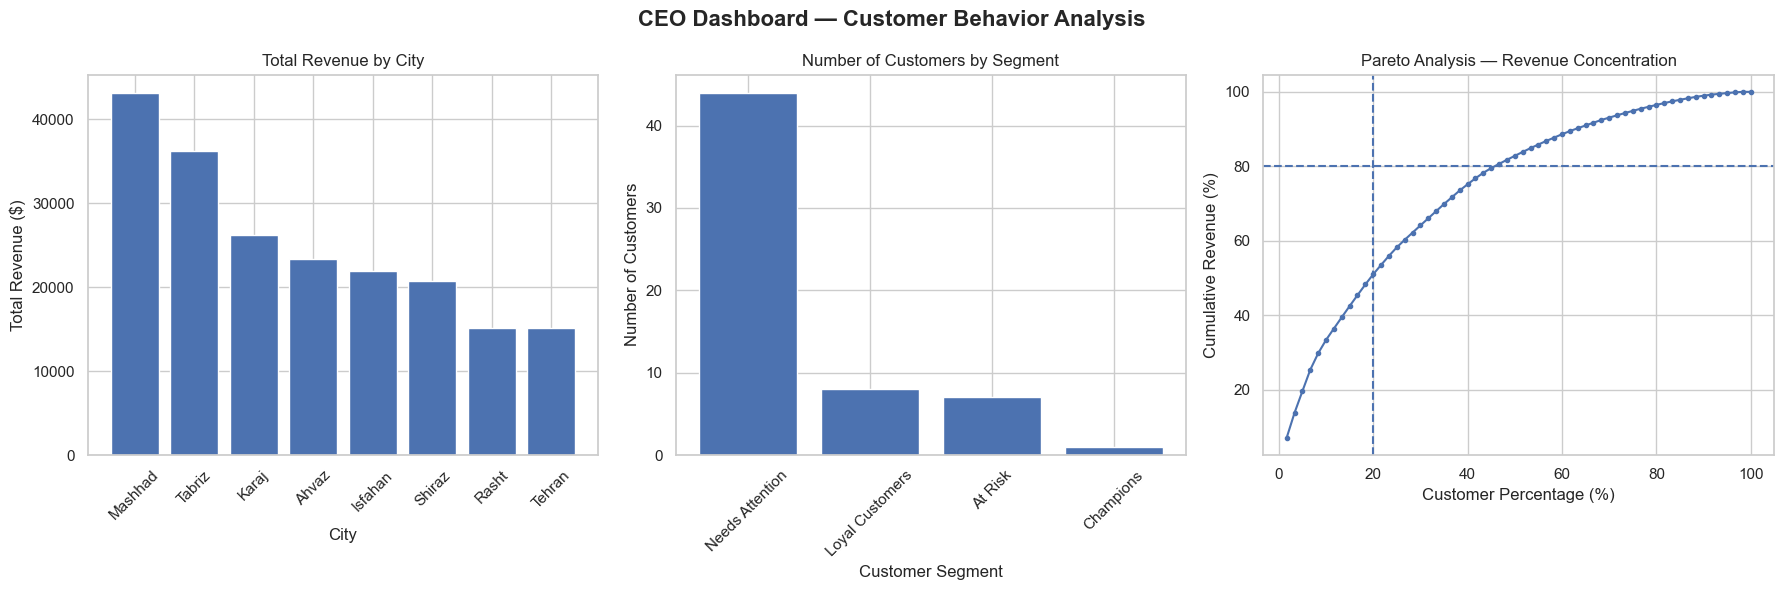

In [51]:
# Question 8 — CEO Dashboard
from pathlib import Path

Path("charts").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------------------------
# Chart 1: Revenue by City
# ---------------------------------

city_revenue = (
    df.groupby("city")["total_spending"]
    .sum()
    .sort_values(ascending=False)
)

axes[0].bar(
    city_revenue.index,
    city_revenue.values
)

axes[0].set_title("Total Revenue by City")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)


# ---------------------------------
# Chart 2: Customer Segments
# ---------------------------------

segment_counts = (
    df["segment"]
    .value_counts()
)

axes[1].bar(
    segment_counts.index,
    segment_counts.values
)

axes[1].set_title("Number of Customers by Segment")
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis="x", rotation=45)


# ---------------------------------
# Chart 3: Pareto Analysis
# ---------------------------------

axes[2].plot(
    pareto_df["customer_pct"],
    pareto_df["cumulative_revenue_pct"],
    marker="o",
    markersize=3
)

axes[2].axhline(
    80,
    linestyle="--",
    linewidth=1.5
)

axes[2].axvline(
    20,
    linestyle="--",
    linewidth=1.5
)

axes[2].set_title("Pareto Analysis — Revenue Concentration")
axes[2].set_xlabel("Customer Percentage (%)")
axes[2].set_ylabel("Cumulative Revenue (%)")


# ---------------------------------
# Dashboard title
# ---------------------------------

fig.suptitle(
    "CEO Dashboard — Customer Behavior Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/08_ceo_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [52]:
df[[
    "customer_id",
    "first_name",
    "total_spending",
    "purchase_count",
    "last_purchase_days",
    "satisfaction_score",
    "segment"
]].head(10)

,customer_id,first_name,total_spending,purchase_count,last_purchase_days,satisfaction_score,segment
0,1001,Reza,2066.01,17,16,5,Loyal Customers
1,1002,Sina,3917.64,12,3,3,Needs Attention
2,1003,Parsa,1248.66,21,22,1,Needs Attention
3,1004,Sina,6121.45,23,40,4,Loyal Customers
4,1005,Kimia,3899.42,23,273,4,Needs Attention
5,1006,Amir,3868.55,35,205,2,Needs Attention
6,1007,Reza,2237.35,29,298,5,At Risk
7,1008,Reza,1168.74,3,195,1,Needs Attention
8,1009,Kimia,11615.42,34,232,2,Needs Attention
9,1010,Arash,7241.47,19,276,1,At Risk


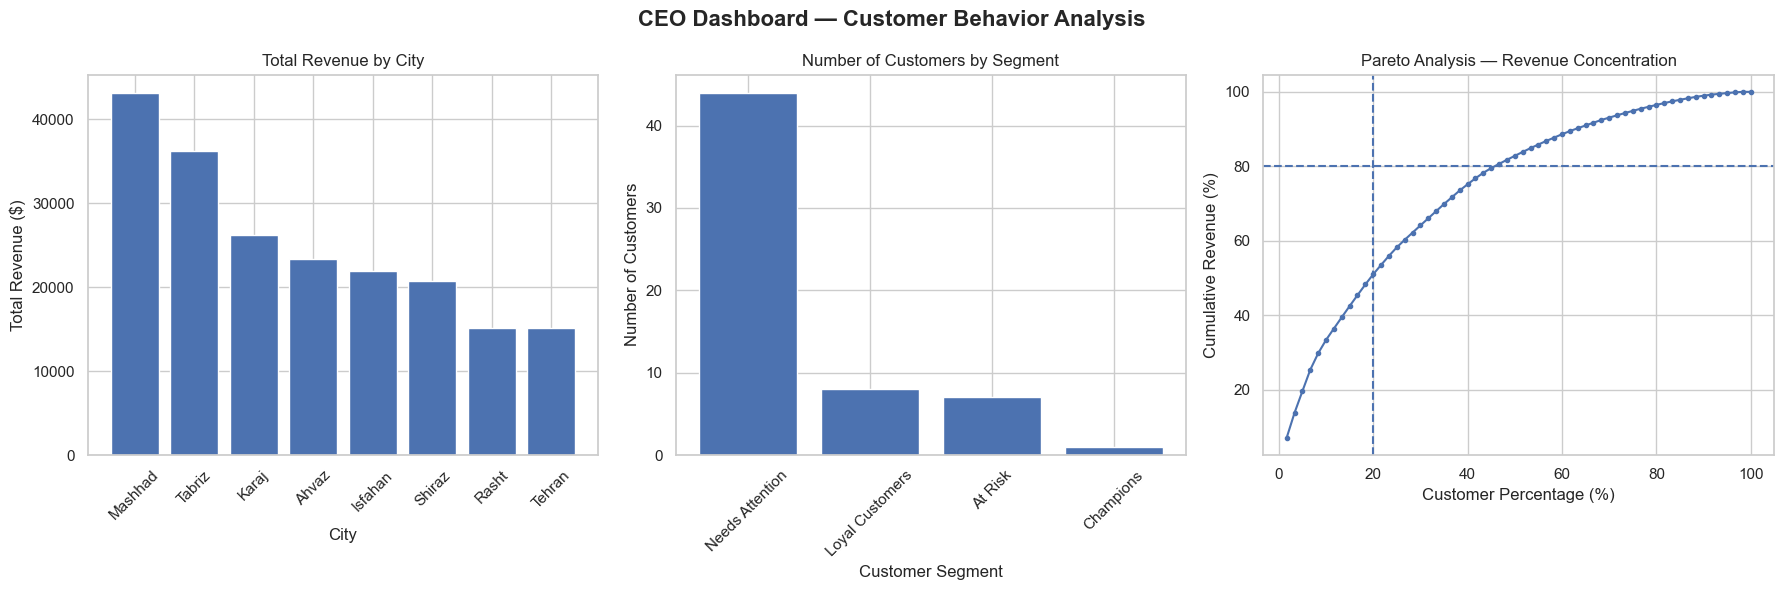

In [53]:
from pathlib import Path

Path("charts").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Revenue by City
city_revenue = (
    df.groupby("city")["total_spending"]
    .sum()
    .sort_values(ascending=False)
)

axes[0].bar(city_revenue.index, city_revenue.values)
axes[0].set_title("Total Revenue by City")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis="x", rotation=45)


# 2. Customer Segments
segment_counts = df["segment"].value_counts()

axes[1].bar(segment_counts.index, segment_counts.values)
axes[1].set_title("Number of Customers by Segment")
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis="x", rotation=45)


# 3. Pareto Analysis
axes[2].plot(
    pareto_df["customer_pct"],
    pareto_df["cumulative_revenue_pct"],
    marker="o",
    markersize=3
)

axes[2].axhline(80, linestyle="--", linewidth=1.5)
axes[2].axvline(20, linestyle="--", linewidth=1.5)

axes[2].set_title("Pareto Analysis — Revenue Concentration")
axes[2].set_xlabel("Customer Percentage (%)")
axes[2].set_ylabel("Cumulative Revenue (%)")


fig.suptitle(
    "CEO Dashboard — Customer Behavior Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/08_ceo_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

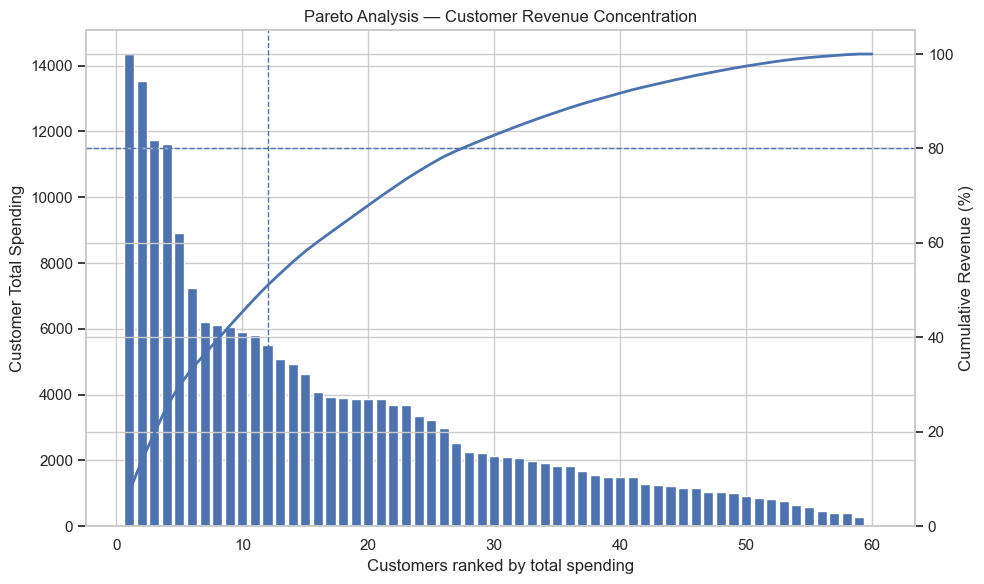

Chart saved successfully:
c:\Users\Smah\Desktop\پروژه 2\charts\07_pareto_revenue.png

Top 20% customers: 12
Top 20% revenue share: 51.00%


In [54]:
# Q7 - Pareto Analysis Chart

import os
import matplotlib.pyplot as plt

# Make sure charts folder exists
os.makedirs("charts", exist_ok=True)

# Sort customers by total spending
pareto_df = df.sort_values(
    "total_spending",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative revenue
pareto_df["cumulative_revenue"] = pareto_df["total_spending"].cumsum()

total_revenue = pareto_df["total_spending"].sum()

pareto_df["cumulative_revenue_pct"] = (
    pareto_df["cumulative_revenue"] / total_revenue
) * 100

# Top 20% customers
top_20_count = int(np.ceil(len(pareto_df) * 0.20))

top_20_revenue = pareto_df.iloc[:top_20_count]["total_spending"].sum()

top_20_revenue_pct = (
    top_20_revenue / total_revenue
) * 100

# Create chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Customer spending bars
ax1.bar(
    range(1, len(pareto_df) + 1),
    pareto_df["total_spending"]
)

ax1.set_xlabel("Customers ranked by total spending")
ax1.set_ylabel("Customer Total Spending")
ax1.set_title("Pareto Analysis — Customer Revenue Concentration")

# Cumulative revenue line
ax2 = ax1.twinx()

ax2.plot(
    range(1, len(pareto_df) + 1),
    pareto_df["cumulative_revenue_pct"],
    linewidth=2
)

# 80% reference line
ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=1
)

# 20% customer reference line
ax2.axvline(
    x=top_20_count,
    linestyle="--",
    linewidth=1
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0, 105)

plt.tight_layout()

# Save chart
chart_path = "charts/07_pareto_revenue.png"

plt.savefig(
    chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:")
print(os.path.abspath(chart_path))

print(f"\nTop 20% customers: {top_20_count}")
print(f"Top 20% revenue share: {top_20_revenue_pct:.2f}%")

### Analysis

The top 20% of customers (12 out of 60 customers) generate 51.00% of total revenue.

This shows that revenue is concentrated among a relatively small group of high-value customers. However, the dataset does not follow the classic 80/20 Pareto rule, because the top 20% of customers generate 51% rather than approximately 80% of revenue.

### Business Risk

High revenue concentration creates a business risk because losing a small number of high-value customers could significantly reduce total revenue.

Therefore, the company should prioritize customer retention and loyalty programs for high-value customers while also developing strategies to increase the value of the remaining customer base.

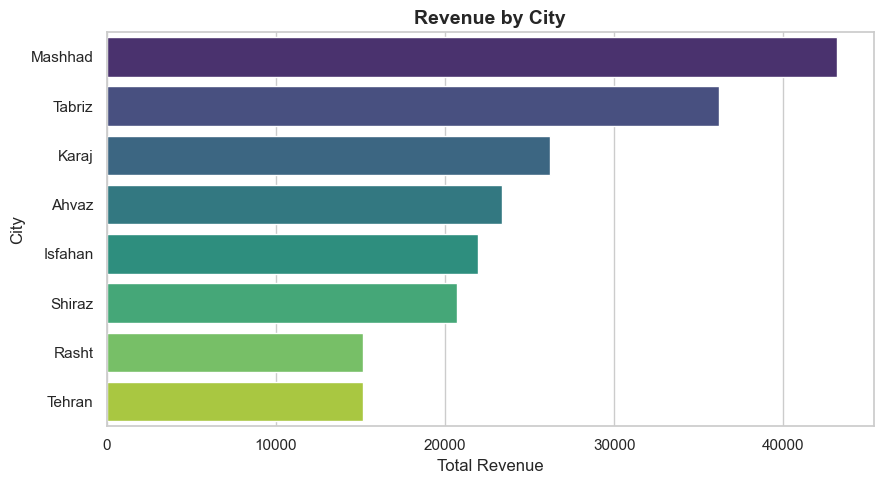

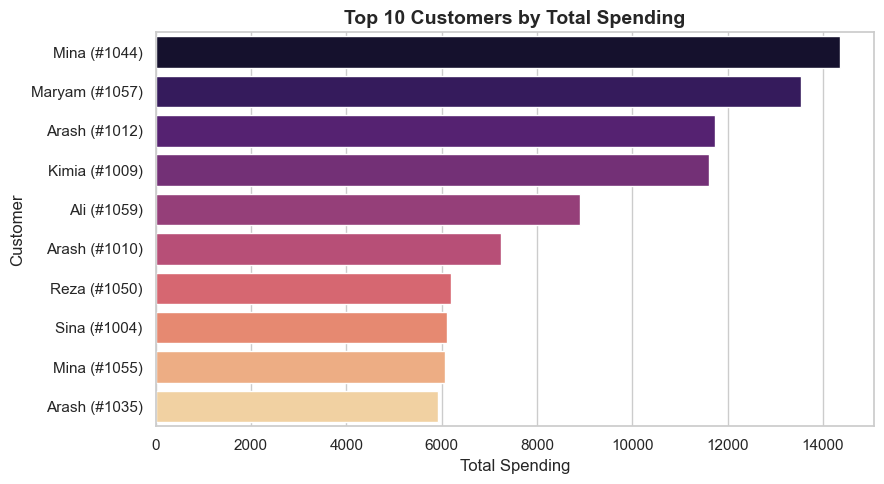

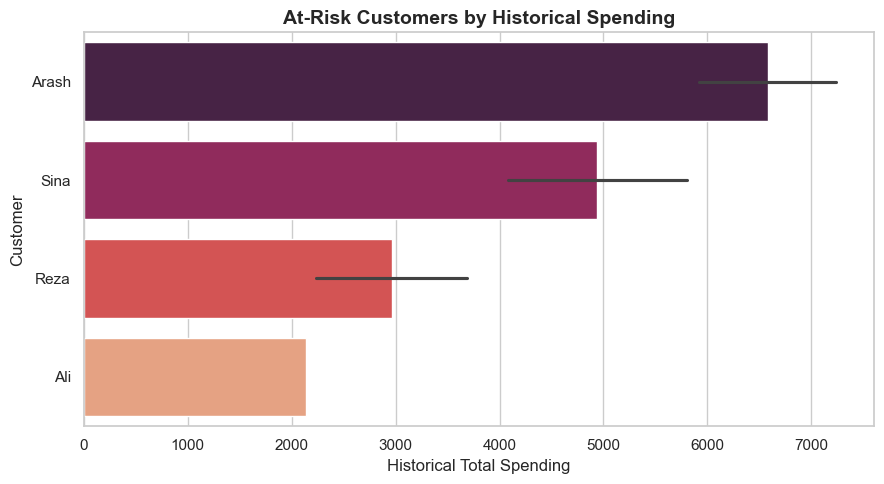

CEO Dashboard charts created successfully.
Revenue by city chart: charts\08_1_revenue_by_city.png
Top 10 customers chart: charts\08_2_top10_customers.png
At-risk customers chart: charts\08_3_at_risk_customers.png


In [55]:
# Question 8 — CEO Dashboard
# Select only 3 charts with the highest managerial value

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Create charts folder if it does not exist
charts_dir = Path("charts")
charts_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Chart 1 — Revenue by City
# ---------------------------------------------------------

city_revenue = (
    df.groupby("city")["total_spending"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=city_revenue.values,
    y=city_revenue.index,
    hue=city_revenue.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue by City", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    charts_dir / "08_1_revenue_by_city.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Chart 2 — Top 10 Customers by Total Spending
# ---------------------------------------------------------

top10 = (
    df.sort_values("total_spending", ascending=False)
    .head(10)
    .copy()
)

top10["customer_label"] = (
    top10["first_name"]
    + " (#"
    + top10["customer_id"].astype(str)
    + ")"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top10,
    x="total_spending",
    y="customer_label",
    hue="customer_label",
    palette="magma",
    legend=False
)

plt.title(
    "Top 10 Customers by Total Spending",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Spending")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    charts_dir / "08_2_top10_customers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Chart 3 — At-Risk Customers
# ---------------------------------------------------------

# Use the same at-risk definition from Question 4
recency_threshold = df["last_purchase_days"].quantile(0.75)

at_risk_df = df[
    (df["last_purchase_days"] >= recency_threshold)
    & (df["total_spending"] >= df["total_spending"].median())
].copy()

at_risk_df = at_risk_df.sort_values(
    "total_spending",
    ascending=False
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=at_risk_df,
    x="total_spending",
    y="first_name",
    hue="first_name",
    palette="rocket",
    legend=False
)

plt.title(
    "At-Risk Customers by Historical Spending",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Historical Total Spending")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    charts_dir / "08_3_at_risk_customers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("CEO Dashboard charts created successfully.")
print(f"Revenue by city chart: {charts_dir / '08_1_revenue_by_city.png'}")
print(f"Top 10 customers chart: {charts_dir / '08_2_top10_customers.png'}")
print(f"At-risk customers chart: {charts_dir / '08_3_at_risk_customers.png'}")

## Question 8 — CEO Dashboard

Only three charts were selected because the CEO has limited time and needs the most actionable information.

### Chart 1 — Revenue by City

**What does it show?**

This chart compares total revenue generated by each city.

**Why is it important?**

It helps management identify which cities currently contribute the most revenue and where the existing customer base has greater commercial value.

**Decision:**

The company can prioritize high-performing cities for marketing campaigns while investigating weaker cities before increasing advertising spending.

---

### Chart 2 — Top 10 Customers by Total Spending

**What does it show?**

This chart identifies the ten customers who have generated the highest historical spending.

**Why is it important?**

A relatively small group of customers contributes a large share of total revenue. Losing these customers could negatively affect business revenue.

**Decision:**

The company should prioritize these customers for loyalty programs, personalized offers, and retention activities.

---

### Chart 3 — At-Risk Customers

**What does it show?**

This chart identifies high-value customers who have not purchased for a relatively long period.

**Why is it important?**

These customers have already generated significant historical revenue but may be at risk of becoming inactive.

**Decision:**

The company should launch a targeted win-back campaign using personalized offers or customer-service follow-up.

### CEO Takeaway

The three charts provide a concise view of where revenue comes from, which customers are most valuable, and which valuable customers may be at risk. Together, they support decisions about marketing allocation, loyalty investment, and customer retention.

In [57]:
# Question 9 — Three Data-Driven Recommendations

# Recreate city statistics
city_stats = df.groupby("city").agg(
    customers=("customer_id", "count"),
    total_purchases=("purchase_count", "sum"),
    total_revenue=("total_spending", "sum"),
    avg_spending_per_customer=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    return_rate=("returned_items", "sum")
).round(2)

# Calculate return rate correctly
city_stats["return_rate"] = (
    df.groupby("city")["returned_items"].sum()
    / df.groupby("city")["purchase_count"].sum()
)

city_stats["return_rate"] = city_stats["return_rate"].round(3)

# Best city
best_city = city_stats["total_revenue"].idxmax()

best_city_revenue = city_stats.loc[best_city, "total_revenue"]
best_city_customers = city_stats.loc[best_city, "customers"]
best_city_purchases = city_stats.loc[best_city, "total_purchases"]
best_city_satisfaction = city_stats.loc[best_city, "avg_satisfaction"]

print("Recommendation 1 — Marketing")
print(f"Best city: {best_city}")
print(f"Revenue: ${best_city_revenue:,.2f}")
print(f"Customers: {best_city_customers}")
print(f"Purchases: {best_city_purchases}")
print(f"Average satisfaction: {best_city_satisfaction:.2f}")

Recommendation 1 — Marketing
Best city: Mashhad
Revenue: $43,197.58
Customers: 11
Purchases: 249
Average satisfaction: 2.91


Question 9 — Three Data-Driven Recommendations
Recommendation 1 — Focus Marketing on Mashhad

Evidence
Mashhad has the highest total revenue among all cities, with $43,197.58 generated from 11 customers and 249 purchases. It also has the highest number of purchases in the dataset.

Action
Allocate the main advertising budget to Mashhad and focus the campaign on acquiring similar customers and encouraging repeat purchases.

KPI

Total Revenue
Number of Customers
Purchase Count
Revenue per Customer
Recommendation 2 — Launch a Win-Back Campaign for At-Risk Customers

Evidence
The analysis identified 7 customers at risk of churn. These customers have relatively long periods since their last purchase and, in most cases, low satisfaction. Together, they represent approximately $31,113.53 in historical revenue.

Action
Create a targeted win-back campaign using personalized offers, limited-time discounts, free shipping, or customer-service follow-up.

KPI

Reactivation Rate
Repeat Purchase Rate
Revenue from Reactivated Customers
Customer Satisfaction
Recommendation 3 — Use Discounts Selectively and Test Their Impact

Evidence
Customers who used discounts showed differences in purchase behavior and satisfaction compared with customers who did not use discounts. However, the observed differences do not prove that discounts caused higher sales.

Action
Do not give discounts to all customers. Run a controlled A/B test with selected customer groups to determine whether discounts actually increase purchases and revenue without increasing returns or reducing profitability.

KPI

Purchase Count
Revenue per Customer
Average Order Value
Return Rate
Customer Satisfaction
Profit Margin


# Question 10 — Dataset Limitations

The dataset provides useful information about customer behavior, but there are several limitations that should be considered before making major business decisions.

### 1. Small Sample Size

The dataset contains only 60 customers. This small sample size limits the reliability and generalizability of statistical analyses. Differences between customer groups may not represent the behavior of the entire customer population.

### 2. No Detailed Transaction History

The dataset contains aggregated variables such as `purchase_count` and `total_spending`, but it does not include individual order dates and transaction-level data. Therefore, it is difficult to analyze purchasing trends, seasonality, or changes in customer behavior over time.

### 3. No Profit or Cost Information

The dataset contains customer spending and revenue-related information, but it does not include product costs, marketing costs, shipping costs, or profit margins. Therefore, revenue cannot be treated as the same as profitability.

### 4. Churn Is Not Directly Observed

There is no actual churn indicator in the dataset. Customers identified as "At Risk" are classified using behavioral rules such as long time since the last purchase and low satisfaction. Therefore, the churn classification is an analytical assumption rather than confirmed customer churn.

### 5. Limited Marketing Information

The dataset does not contain information about advertising campaigns, acquisition channels, advertising costs, or campaign performance. Therefore, we cannot accurately calculate customer acquisition cost (CAC) or determine which marketing channel generates the highest return.

### Additional Data That Would Improve the Analysis

The following variables could significantly improve future analysis:

- Customer signup date
- Exact order date
- Order ID
- Product category
- Product price
- Product cost
- Shipping cost
- Profit per order
- Marketing campaign cost
- Customer acquisition channel
- Advertising source
- Discount amount
- Discount percentage
- Actual churn status
- Customer support interactions
- Order cancellation information

### Conclusion

The current dataset is sufficient for identifying customer segments, comparing cities, identifying high-value customers, detecting potential churn risk, and generating initial business recommendations. However, future decisions would be more reliable if the company collected transaction-level, profitability, marketing, and customer lifecycle data.